Import the libraries

In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

Database Connection

In [ ]:
connection = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="your_password",
    database= "data_analytics_project"
)

if connection.is_connected():
    print("Connected successfully!")


Connected successfully!


SQL Query

In [3]:
query = "SELECT * FROM sales"

Read the SQL result into Pandas

In [4]:
df = pd.read_sql(query, connection)

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1848774206.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Display the data

In [6]:
print("DATA:")
print(df.to_string())

DATA:
    OrderID   OrderDate   Product     Category     Region Salesperson  Quantity     Sales
0      1001  2026-01-05    Laptop  Electronics    Chennai        Arun         2  120000.0
1      1002  2026-01-08     Mouse  Accessories    Chennai       Priya         5    7500.0
2      1003  2026-01-12  Keyboard  Accessories  Bangalore       Rahul         3    9000.0
3      1004  2026-01-15   Monitor  Electronics     Mumbai       Sneha         2   50000.0
4      1005  2026-01-20   Printer  Electronics      Delhi        Arun         1   18000.0
5      1006  2026-02-03    Laptop  Electronics  Bangalore       Rahul         1   60000.0
6      1007  2026-02-07     Mouse  Accessories     Mumbai       Sneha         8   12000.0
7      1008  2026-02-14  Keyboard  Accessories      Delhi       Priya         4   12000.0
8      1009  2026-02-18   Monitor  Electronics    Chennai        Arun         3   75000.0
9      1010  2026-02-25   Printer  Electronics  Bangalore       Rahul         2   36000.0
10  

Inspect the Data

In [9]:
print("First 5 Rows:")
print(df.head().to_string())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

First 5 Rows:
   OrderID   OrderDate   Product     Category     Region Salesperson  Quantity     Sales
0     1001  2026-01-05    Laptop  Electronics    Chennai        Arun         2  120000.0
1     1002  2026-01-08     Mouse  Accessories    Chennai       Priya         5    7500.0
2     1003  2026-01-12  Keyboard  Accessories  Bangalore       Rahul         3    9000.0
3     1004  2026-01-15   Monitor  Electronics     Mumbai       Sneha         2   50000.0
4     1005  2026-01-20   Printer  Electronics      Delhi        Arun         1   18000.0

Shape:
(20, 8)

Columns:
Index(['OrderID', 'OrderDate', 'Product', 'Category', 'Region', 'Salesperson',
       'Quantity', 'Sales'],
      dtype='str')


All KPIs in One Query

In [10]:
query = """
SELECT
    SUM(Sales) AS Total_Sales,
    COUNT(*) AS Total_Orders,
    AVG(Sales) AS Average_Sales,
    MAX(Sales) AS Highest_Sales,
    MIN(Sales) AS Lowest_Sales
FROM sales
"""

kpi = pd.read_sql(query, connection)

print(kpi)

   Total_Sales  Total_Orders  Average_Sales  Highest_Sales  Lowest_Sales
0     864500.0            20        43225.0       120000.0        7500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1139443583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  kpi = pd.read_sql(query, connection)


Category-wise Sales Analysis

In [11]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
"""

df_category = pd.read_sql(query, connection)

print(df_category)

      Category  Total_Sales
0  Electronics     764000.0
1  Accessories     100500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\37601885.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category = pd.read_sql(query, connection)


Find the Highest-Selling Category

In [12]:
highest_category = df_category.loc[
    df_category["Total_Sales"].idxmax()
]

print(highest_category)

Category       Electronics
Total_Sales       764000.0
Name: 0, dtype: object


Region-wise Sales Analysis

In [13]:
query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
"""

df_region = pd.read_sql(query, connection)

print(df_region)

      Region  Total_Sales
0     Mumbai     286000.0
1    Chennai     226500.0
2      Delhi     201000.0
3  Bangalore     151000.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1103786073.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_region = pd.read_sql(query, connection)


Find the highest-selling region

In [14]:
highest_region = df_region.loc[
    df_region["Total_Sales"].idxmax()
]

print(highest_region)

Region           Mumbai
Total_Sales    286000.0
Name: 0, dtype: object


Salesperson-wise Sales Analysis

In [15]:
query = """
SELECT
    Salesperson,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Salesperson
ORDER BY Total_Sales DESC
"""

df_salesperson = pd.read_sql(query, connection)

print(df_salesperson)

  Salesperson  Total_Sales
0       Sneha     286000.0
1        Arun     237000.0
2       Priya     190500.0
3       Rahul     151000.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\3483309903.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_salesperson = pd.read_sql(query, connection)


Find the best salesperson

In [16]:
best_salesperson = df_salesperson.loc[
    df_salesperson["Total_Sales"].idxmax()
]

print(best_salesperson)

Salesperson       Sneha
Total_Sales    286000.0
Name: 0, dtype: object


Product-wise Sales Analysis

In [17]:
query = """
SELECT
    Product,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
"""

df_product = pd.read_sql(query, connection)

print(df_product)

    Product  Total_Sales
0    Laptop     420000.0
1   Monitor     200000.0
2   Printer     144000.0
3  Keyboard      57000.0
4     Mouse      43500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1276271756.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql(query, connection)


Find the best-selling product

In [18]:
best_product = df_product.loc[
    df_product["Total_Sales"].idxmax()
]

print(best_product)

Product          Laptop
Total_Sales    420000.0
Name: 0, dtype: object


Quantity Analysis



In [19]:
query = """
SELECT
    Product,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Product
ORDER BY Total_Quantity DESC
"""

df_quantity = pd.read_sql(query, connection)

print(df_quantity)

    Product  Total_Quantity
0     Mouse            29.0
1  Keyboard            19.0
2   Monitor             8.0
3   Printer             8.0
4    Laptop             7.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\3339086033.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_quantity = pd.read_sql(query, connection)


Find the product with the highest quantity sold

In [20]:
best_quantity_product = df_quantity.loc[
    df_quantity["Total_Quantity"].idxmax()
]

print(best_quantity_product)

Product           Mouse
Total_Quantity     29.0
Name: 0, dtype: object


Average Sales by Region

In [21]:
query = """
SELECT
    Region,
    AVG(Sales) AS Average_Sales
FROM sales
GROUP BY Region
ORDER BY Average_Sales DESC
"""

df_avg_region = pd.read_sql(query, connection)

print(df_avg_region)

      Region  Average_Sales
0     Mumbai        57200.0
1    Chennai        45300.0
2      Delhi        40200.0
3  Bangalore        30200.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\2133125833.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_avg_region = pd.read_sql(query, connection)


Find the Region with Highest Average Sales

In [22]:
highest_avg_region = df_avg_region.loc[
    df_avg_region["Average_Sales"].idxmax()
]

print(highest_avg_region)

Region            Mumbai
Average_Sales    57200.0
Name: 0, dtype: object


Monthly Sales Analysis

In [23]:
query = """
SELECT
    DATE_FORMAT(OrderDate, '%Y-%m') AS Month,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY DATE_FORMAT(OrderDate, '%Y-%m')
ORDER BY Month
"""

df_monthly = pd.read_sql(query, connection)

print(df_monthly)

     Month  Total_Sales
0  2026-01     204500.0
1  2026-02     195000.0
2  2026-03     229000.0
3  2026-04     236000.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1406316603.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly = pd.read_sql(query, connection)


Find the Highest-Sales Month

In [24]:
highest_month = df_monthly.loc[
    df_monthly["Total_Sales"].idxmax()
]

print(highest_month)

Month           2026-04
Total_Sales    236000.0
Name: 3, dtype: object


Create Monthly Sales Line Chart

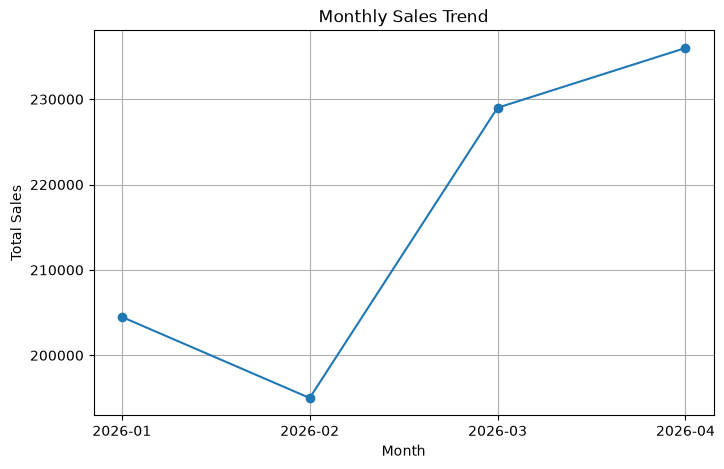

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df_monthly["Month"],
    df_monthly["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()

plt.show()

Category-wise Sales Bar Chart

In [26]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
"""

df_category = pd.read_sql(query, connection)

print(df_category)

      Category  Total_Sales
0  Electronics     764000.0
1  Accessories     100500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\37601885.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category = pd.read_sql(query, connection)


Create the Bar Chart

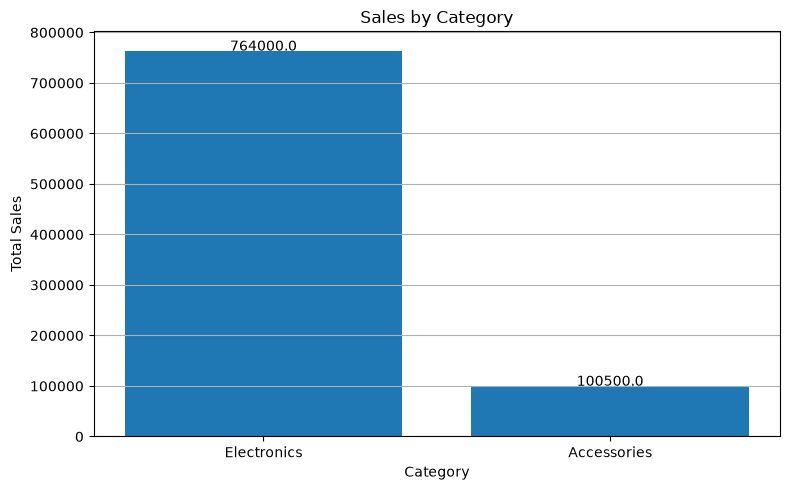

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_category["Category"],
    df_category["Total_Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_category["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.show()

Region-wise Sales Bar Chart

In [28]:
query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
"""

df_region = pd.read_sql(query, connection)

print(df_region)

      Region  Total_Sales
0     Mumbai     286000.0
1    Chennai     226500.0
2      Delhi     201000.0
3  Bangalore     151000.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1103786073.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_region = pd.read_sql(query, connection)


Create the Bar Chart

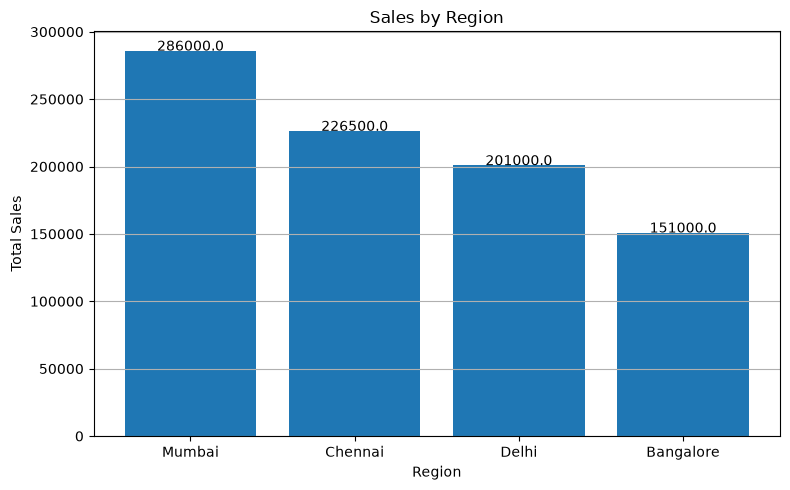

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_region["Region"],
    df_region["Total_Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_region["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.show()

Salesperson-wise Sales Bar Chart

In [30]:
query = """
SELECT
    Salesperson,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Salesperson
ORDER BY Total_Sales DESC
"""

df_salesperson = pd.read_sql(query, connection)

print(df_salesperson)

  Salesperson  Total_Sales
0       Sneha     286000.0
1        Arun     237000.0
2       Priya     190500.0
3       Rahul     151000.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\3483309903.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_salesperson = pd.read_sql(query, connection)


Create the Bar Chart

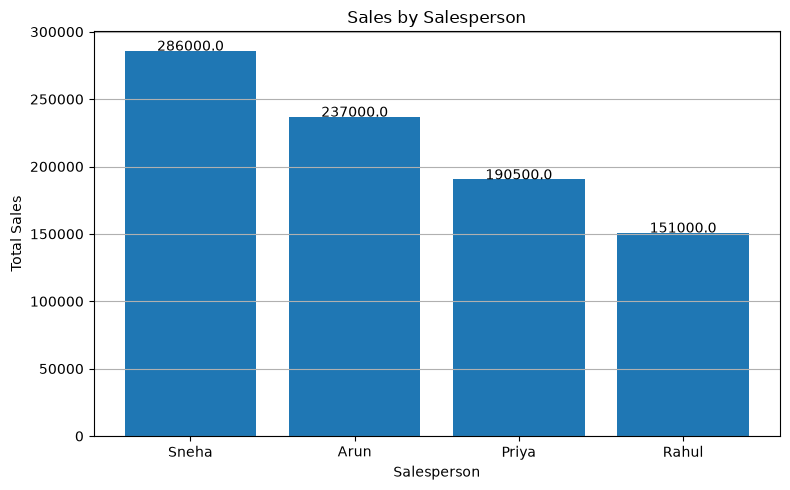

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_salesperson["Salesperson"],
    df_salesperson["Total_Sales"]
)

plt.title("Sales by Salesperson")
plt.xlabel("Salesperson")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_salesperson["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.show()

Product-wise Sales Bar Chart

In [32]:
query = """
SELECT
    Product,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
"""

df_product = pd.read_sql(query, connection)

print(df_product)

    Product  Total_Sales
0    Laptop     420000.0
1   Monitor     200000.0
2   Printer     144000.0
3  Keyboard      57000.0
4     Mouse      43500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1276271756.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql(query, connection)


Create the Bar Chart

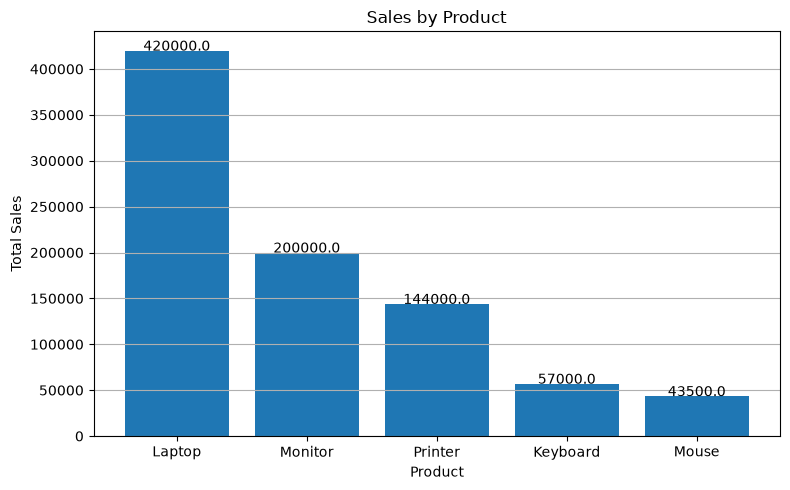

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_product["Product"],
    df_product["Total_Sales"]
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_product["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.show()

Quantity-wise Product Analysis

In [34]:
query = """
SELECT
    Product,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Product
ORDER BY Total_Quantity DESC
"""

df_quantity = pd.read_sql(query, connection)

print(df_quantity)

    Product  Total_Quantity
0     Mouse            29.0
1  Keyboard            19.0
2   Monitor             8.0
3   Printer             8.0
4    Laptop             7.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\3339086033.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_quantity = pd.read_sql(query, connection)


Create the Bar Chart

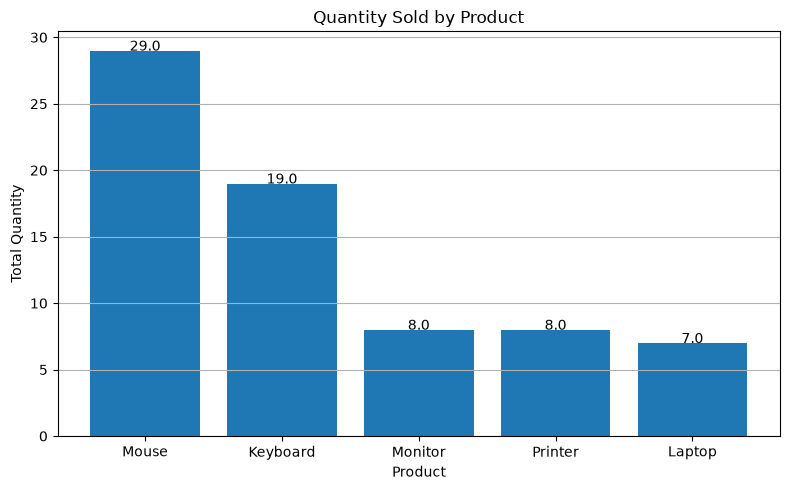

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_quantity["Product"],
    df_quantity["Total_Quantity"]
)

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.grid(axis="y")

for i, value in enumerate(df_quantity["Total_Quantity"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.show()

Sales Distribution Pie Chart

In [36]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
"""

df_category = pd.read_sql(query, connection)

print(df_category)

      Category  Total_Sales
0  Electronics     764000.0
1  Accessories     100500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\338415694.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category = pd.read_sql(query, connection)


Create the Pie Chart

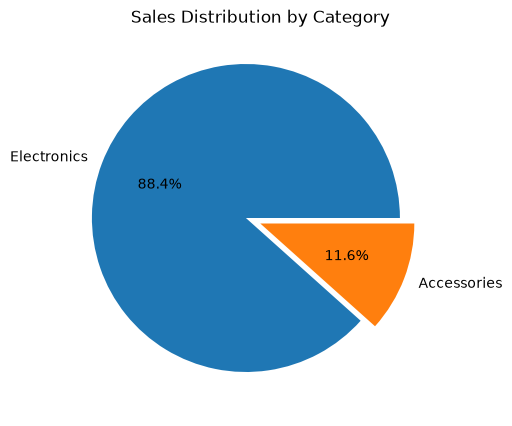

In [38]:
plt.figure(figsize=(8, 5))

explode = [0.1,0]

plt.pie(
    df_category["Total_Sales"],
    labels=df_category["Category"],
    autopct="%1.1f%%",
    explode=explode
)

plt.title("Sales Distribution by Category")

plt.show()

Monthly Sales Line Chart with Data Labels

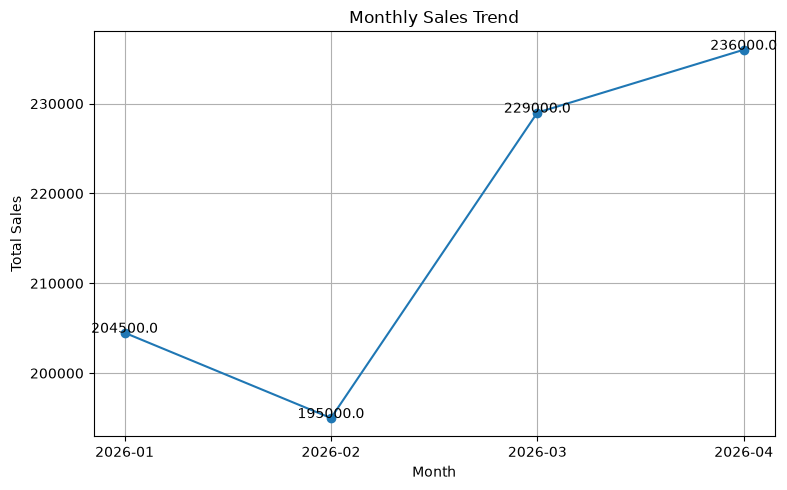

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df_monthly["Month"],
    df_monthly["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()

for i, value in enumerate(df_monthly["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.show()

Save Project Charts

Monthly Sales Chart

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\3469417229.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly = pd.read_sql(query, connection)


     Month  Total_Sales
0  2026-01     204500.0
1  2026-02     195000.0
2  2026-03     229000.0
3  2026-04     236000.0


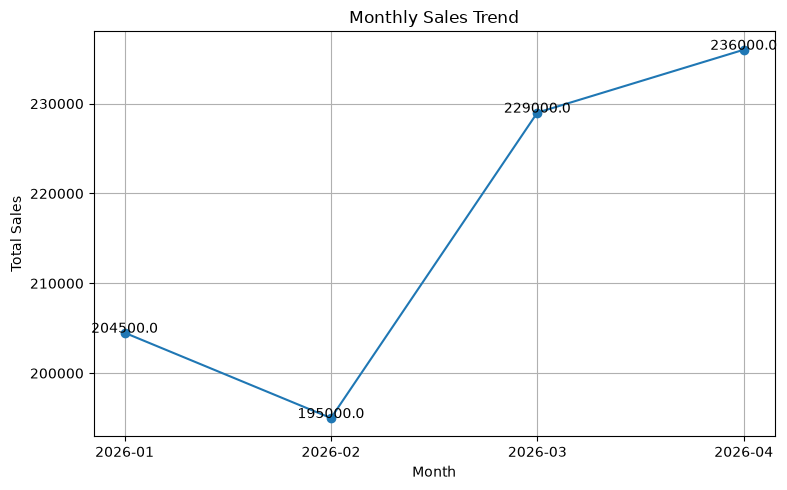

In [58]:
# Monthly Sales Chart

query = """
SELECT
    DATE_FORMAT(OrderDate, '%Y-%m') AS Month,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY DATE_FORMAT(OrderDate, '%Y-%m')
ORDER BY Month
"""

df_monthly = pd.read_sql(query, connection)

print(df_monthly)

plt.figure(figsize=(8, 5))

plt.plot(
    df_monthly["Month"],
    df_monthly["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()

for i, value in enumerate(df_monthly["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()

plt.savefig("charts/monthly_sales.png", dpi=300)

plt.show()

Category Chart

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\2619891970.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category = pd.read_sql(query, connection)


      Category  Total_Sales
0  Electronics     764000.0
1  Accessories     100500.0


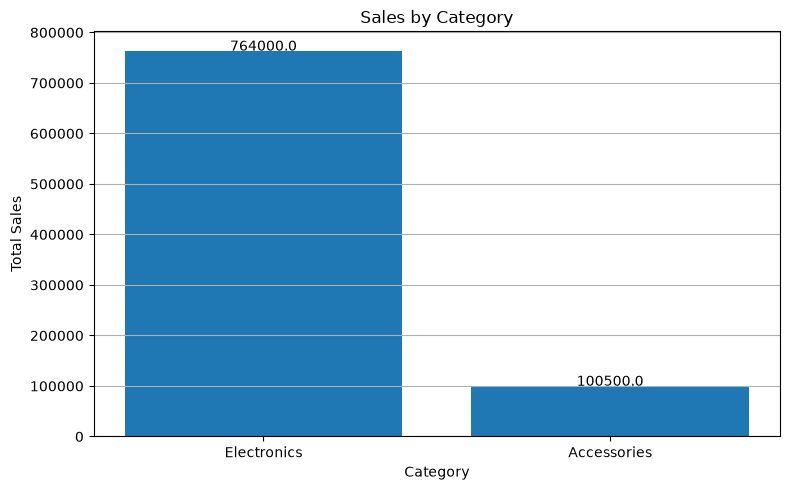

In [51]:
# Category Sales Chart

query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
"""

df_category = pd.read_sql(query, connection)

print(df_category)

plt.figure(figsize=(8, 5))

plt.bar(
    df_category["Category"],
    df_category["Total_Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_category["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()

plt.savefig("charts/category_sales.png", dpi=300)

plt.show()

Region Chart

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1760656501.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_region = pd.read_sql(query, connection)


      Region  Total_Sales
0     Mumbai     286000.0
1    Chennai     226500.0
2      Delhi     201000.0
3  Bangalore     151000.0


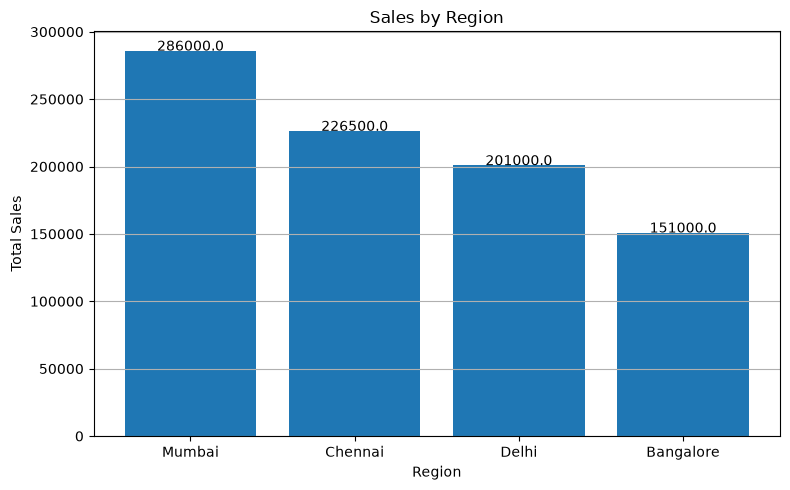

In [52]:
# Region Sales Chart

query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
"""

df_region = pd.read_sql(query, connection)

print(df_region)

plt.figure(figsize=(8, 5))

plt.bar(
    df_region["Region"],
    df_region["Total_Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_region["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()

plt.savefig("charts/region_sales.png", dpi=300)

plt.show()

Salesperson Chart

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\217931958.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_salesperson = pd.read_sql(query, connection)


  Salesperson  Total_Sales
0       Sneha     286000.0
1        Arun     237000.0
2       Priya     190500.0
3       Rahul     151000.0


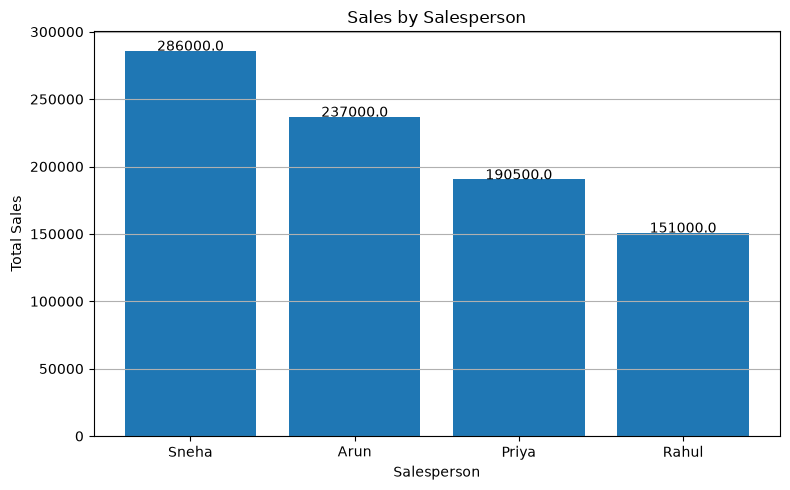

In [53]:
# Salesperson Sales Chart

query = """
SELECT
    Salesperson,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Salesperson
ORDER BY Total_Sales DESC
"""

df_salesperson = pd.read_sql(query, connection)

print(df_salesperson)

plt.figure(figsize=(8, 5))

plt.bar(
    df_salesperson["Salesperson"],
    df_salesperson["Total_Sales"]
)

plt.title("Sales by Salesperson")
plt.xlabel("Salesperson")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_salesperson["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()

plt.savefig("charts/salesperson_sales.png", dpi=300)

plt.show()

Product Chart

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\3308388950.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql(query, connection)


    Product  Total_Sales
0    Laptop     420000.0
1   Monitor     200000.0
2   Printer     144000.0
3  Keyboard      57000.0
4     Mouse      43500.0


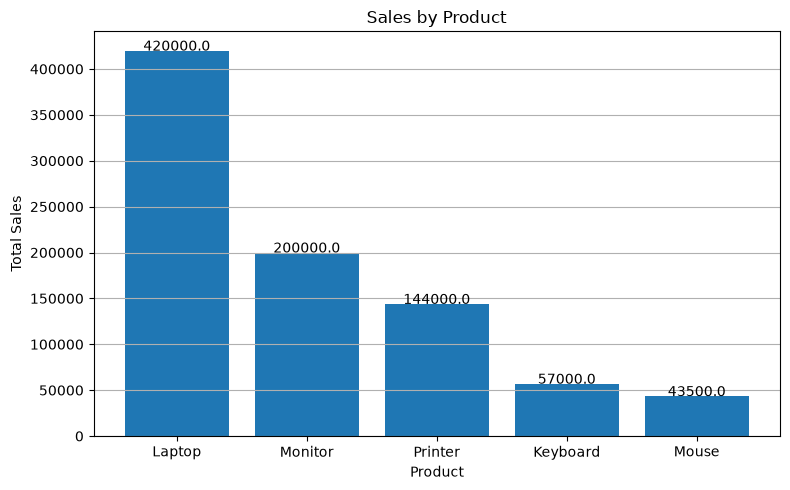

In [54]:
# Product Sales Chart

query = """
SELECT
    Product,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
"""

df_product = pd.read_sql(query, connection)

print(df_product)

plt.figure(figsize=(8, 5))

plt.bar(
    df_product["Product"],
    df_product["Total_Sales"]
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.grid(axis="y")

for i, value in enumerate(df_product["Total_Sales"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()

plt.savefig("charts/product_sales.png", dpi=300)

plt.show()

Quantity Chart

C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\204796948.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_quantity = pd.read_sql(query, connection)


    Product  Total_Quantity
0     Mouse            29.0
1  Keyboard            19.0
2   Monitor             8.0
3   Printer             8.0
4    Laptop             7.0


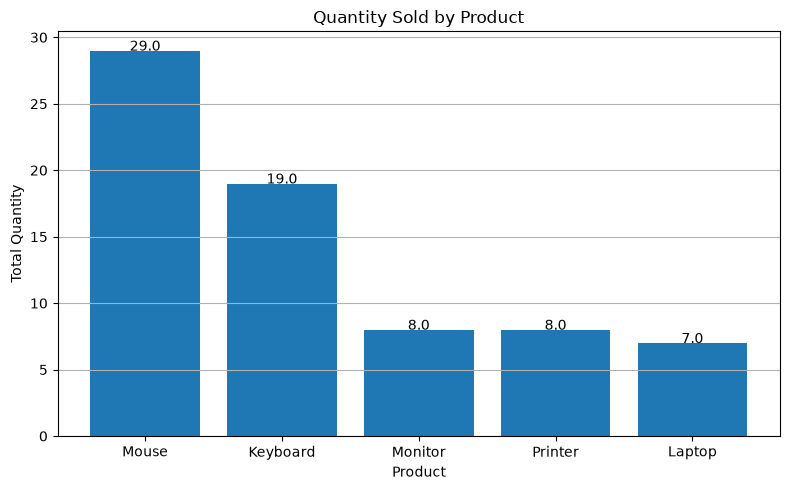

In [55]:
# Product Quantity Chart

query = """
SELECT
    Product,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Product
ORDER BY Total_Quantity DESC
"""

df_quantity = pd.read_sql(query, connection)

print(df_quantity)

plt.figure(figsize=(8, 5))

plt.bar(
    df_quantity["Product"],
    df_quantity["Total_Quantity"]
)

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.grid(axis="y")

for i, value in enumerate(df_quantity["Total_Quantity"]):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()

plt.savefig("charts/product_quantity.png", dpi=300)

plt.show()

Category Sales Distribution — Pie Chart

      Category  Total_Sales
0  Electronics     764000.0
1  Accessories     100500.0


C:\Users\jeeva\AppData\Local\Temp\ipykernel_13664\1864669762.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category = pd.read_sql(query, connection)


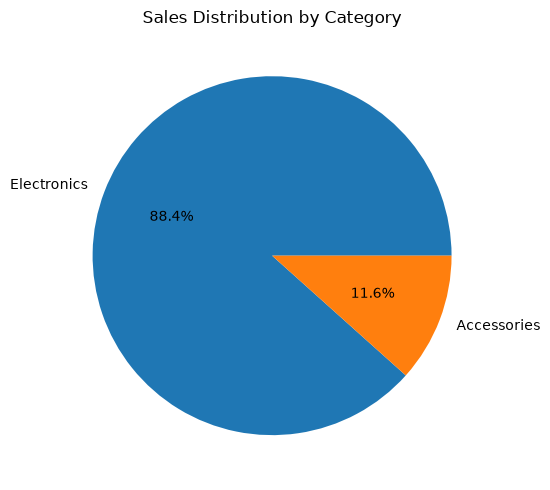

In [57]:
# Category Sales Distribution

query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
"""

df_category = pd.read_sql(query, connection)

print(df_category)

plt.figure(figsize=(8, 5))

plt.pie(
    df_category["Total_Sales"],
    labels=df_category["Category"],
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Category")

plt.tight_layout()

plt.savefig("charts/category_distribution.png", dpi=300)

plt.show()